In [1]:
# 1 Import Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [3]:
# 2 Load Dataset

df = pd.read_csv("liquidity risk.csv")

print("Original Dataset Shape:", df.shape)

Original Dataset Shape: (5000, 20)


In [5]:
# 3 Remove Duplicate Rows

print("Duplicate Rows Before:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate Rows After:", df.duplicated().sum())
print("New Dataset Shape:", df.shape)

Duplicate Rows Before: 1425
Duplicate Rows After: 0
New Dataset Shape: (3575, 20)


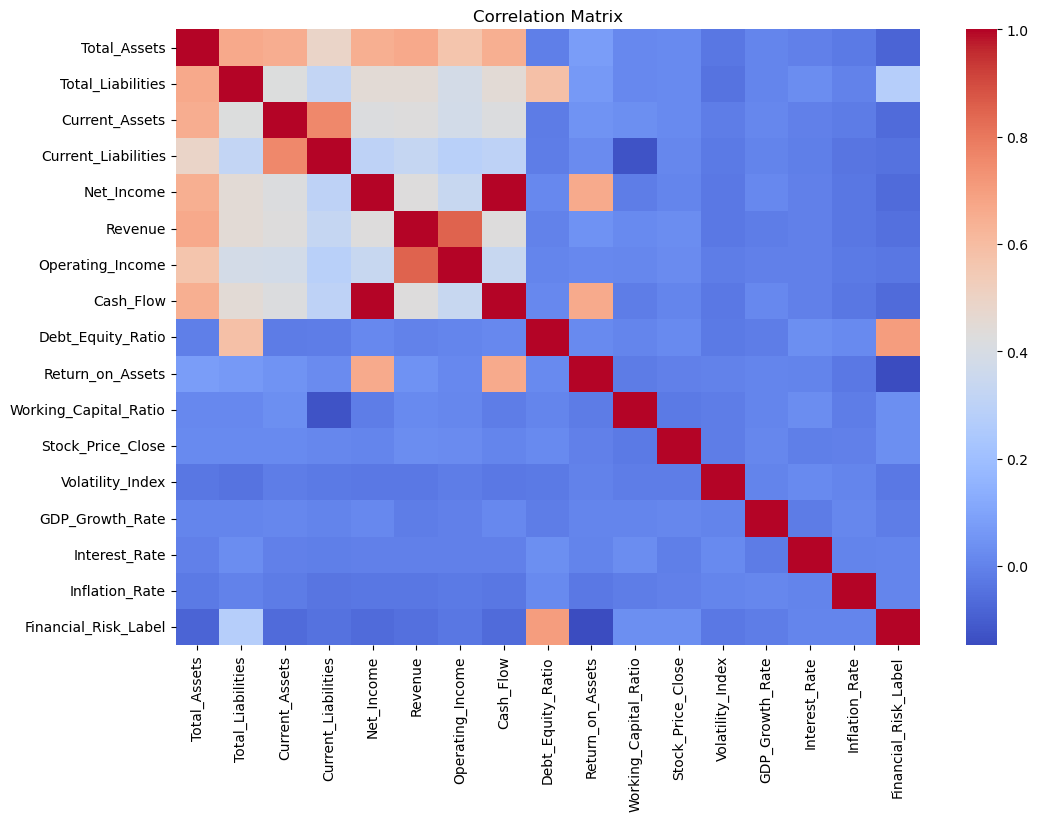

In [7]:
# 4 Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [9]:
# 5 Feature Selection

keep_features = [
    "Debt_Equity_Ratio",
    "Total_Liabilities",
    "Return_on_Assets",
    "Current_Assets",
    "Total_Assets",
    "Net_Income"
]

df_final = df[keep_features + ["Financial_Risk_Label"]]

print("Final Dataset Shape:", df_final.shape)



Final Dataset Shape: (3575, 7)


In [11]:
# 6 Missing Values Check

print(df_final.isnull().sum())

Debt_Equity_Ratio       0
Total_Liabilities       0
Return_on_Assets        0
Current_Assets          0
Total_Assets            0
Net_Income              0
Financial_Risk_Label    0
dtype: int64


In [13]:
# 7 Log Transform (Large Values)

for col in ["Total_Liabilities","Current_Assets","Total_Assets","Net_Income"]:
    df_final[col] = np.log1p(df_final[col])

C:\Users\bipin\AppData\Local\Temp\ipykernel_5892\1754084742.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[col] = np.log1p(df_final[col])
C:\Users\bipin\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [15]:
# 8 Feature Target Split

X = df_final[keep_features]
y = df_final["Financial_Risk_Label"]


In [17]:
# 9 Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [19]:
# 10 Normalization

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
X_train

array([[0.16876574, 0.80552679, 0.90200794, 0.82203785, 0.86016911,
        0.85359615],
       [0.12846348, 0.79688037, 0.77407719, 0.88583097, 0.875119  ,
        0.63100128],
       [0.04785894, 0.71431346, 0.90441265, 0.65738174, 0.8830103 ,
        0.87098961],
       ...,
       [0.19143577, 0.9096744 , 0.85114825, 0.86623234, 0.97825538,
        0.88969197],
       [0.01259446, 0.57343731, 0.9400024 , 0.68377874, 0.9030248 ,
        0.9071048 ],
       [0.53904282, 0.84411564, 0.8725502 , 0.71056178, 0.82883941,
        0.80845952]])

In [27]:
X_test

array([[0.41309824, 0.76271368, 0.863773  , 0.70423337, 0.74180791,
        0.7404098 ],
       [0.43828715, 0.77284493, 0.89731874, 0.73432324, 0.75124985,
        0.77536908],
       [0.70277078, 0.81676266, 0.89743898, 0.65405438, 0.7836632 ,
        0.79776392],
       ...,
       [0.00251889, 0.28377962, 0.94865937, 0.77159688, 0.74850962,
        0.80575033],
       [0.16372796, 0.90193288, 0.8604064 , 0.85710045, 0.98142612,
        0.90166903],
       [0.34256927, 0.95849803, 0.86485512, 0.94179361, 0.99544818,
        0.9157617 ]])

In [29]:
# 11 Model Training

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8,
                       min_samples_split=10, n_estimators=200, random_state=42)

In [31]:
# 12 Predictions

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


In [33]:
# 13 Accuracy Check

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nTraining Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)


Training Accuracy: 1.0
Testing Accuracy: 1.0


In [35]:
# 14 Overfitting Check

if train_accuracy - test_accuracy > 0.10:
    print("⚠️ Model Overfitting kar raha hai")
elif test_accuracy > train_accuracy:
    print("⚠️ Model Underfitting ho sakta hai")
else:
    print("✅ Model Balanced hai (No major overfitting)")


✅ Model Balanced hai (No major overfitting)


In [37]:
# 15 Classification Report

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       593
           1       1.00      1.00      1.00       122

    accuracy                           1.00       715
   macro avg       1.00      1.00      1.00       715
weighted avg       1.00      1.00      1.00       715



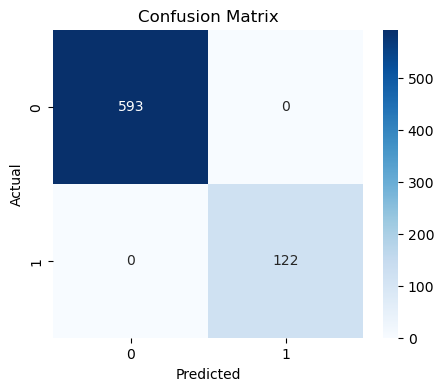

In [39]:
# 16 Confusion Matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Feature Importance:
             Feature  Importance
0  Debt_Equity_Ratio    0.700395
5         Net_Income    0.099710
2   Return_on_Assets    0.085504
1  Total_Liabilities    0.070547
4       Total_Assets    0.033343
3     Current_Assets    0.010502


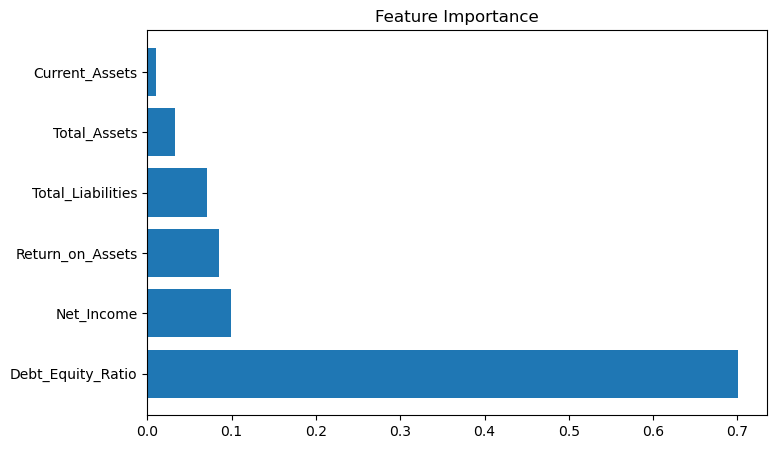

In [41]:
# 17 Feature Importance

importance = model.feature_importances_

imp_df = pd.DataFrame({
    "Feature": keep_features,
    "Importance": importance
})

imp_df = imp_df.sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(imp_df)

plt.figure(figsize=(8,5))
plt.barh(imp_df["Feature"], imp_df["Importance"])
plt.title("Feature Importance")
plt.show()


In [ ]:
joblib.dump(model, "liquidity_risk_model.pkl")
joblib.dump(scaler, "scaler.pkl")